# Bit-exact reproducibility: capturing and replaying a simulation

"Did this simulation match the one in the paper?" is the question every engineering deliverable lives or dies on. Most simulation tools answer "probably" — exact bit-equality across machine, OS, dependency versions, and accidental code edits is rare even when it is claimed. A regulator, a flight-readiness review board, or your future self six months from now wants something stronger than "probably": a notarized receipt that pins down exactly what was simulated, with what numerical kernel, against what library versions, and whose contents can be re-verified on demand.

Jaxonomy ships that receipt as a **`ProvenanceManifest`** — a frozen, JSON-serialisable dataclass returned attached to `SimulationResults` whenever `SimulatorOptions(record_provenance=True)`. The manifest captures library versions, the resolved precision policy, the relevant `SimulatorOptions` fields, a deterministic system fingerprint, the git HEAD of the code that ran, and a single `config_hash` SHA-256 that collapses "what would change the numerical output" into one comparable string. In this notebook we (1) run a simulation with provenance recording on, (2) inspect and persist the manifest as JSON, (3) replay the simulation on the same machine and byte-compare the outputs against the original, and (4) deliberately tamper with the model — first at the float64 ULP scale, then at the source-code level — and watch the manifest catch both.

We close with the precise contract the manifest underwrites (and the corners it deliberately does *not* cover), pointing at `test/determinism/POLICY.md` for the maintainer-facing version. No commercial control-systems tool we are aware of emits a provenance manifest by default; this is one of the trust-building wedges that distinguishes a JAX-based simulator built around explicit functional state from a black-box GUI.

**Estimated reading time:** 15–20 minutes. **Estimated runtime on CPU:** ~25 seconds (no GPU required).

**Prerequisites:** comfort with `LeafSystem` / `simulate` / `SimulatorOptions` (see [`primitives.ipynb`](primitives.ipynb)). Familiarity with JSON / SHA-256 at a hand-wave level. The sibling [`linearization_workflow.ipynb`](linearization_workflow.ipynb) and [`aleatoric_vs_epistemic_uq.ipynb`](aleatoric_vs_epistemic_uq.ipynb) tutorials do not assume reproducibility content; this one stands alone.

## What the manifest is, what it is not

Before we touch any code, a precise mental model. A provenance manifest is a **fingerprint**, not a **snapshot of state**. Specifically:

| Field | What it records | Why it matters |
|---|---|---|
| `jaxonomy_version`, `jax_version`, `numpy_version` | Library identity strings | A 0.4.x → 0.5.x JAX upgrade can shift XLA fusion order; the manifest exposes that risk explicitly. |
| `precision_info` | x64 enabled? default float dtype? machine epsilon? | Float32 vs float64 sims are *not* comparable bit-for-bit. |
| `options` | The relevant `SimulatorOptions` fields (solver, rtol/atol, `max_major_steps`, …) | Two runs with different `rtol` are different simulations, not the same simulation with noise. |
| `system` | A dict with `type`, `system_id`, sorted `parameter_names`, and a SHA-256 hash | Catches structural model changes — added inputs, renamed parameters, swapped subsystems. |
| `timestamp` | ISO-8601 UTC wall clock at `simulate(...)` call | Self-describing; *deliberately excluded* from `config_hash`. |
| `git_head_sha`, `git_branch`, `git_dirty`, `git_head_commit_time` | git metadata of the working directory | Pins the source revision; flags uncommitted edits. |
| `config_hash` | A deterministic SHA-256 over `options + system fingerprint + jaxonomy/jax versions` | Within a single Python process, equality means "should produce identical bytes." Across processes, see §4 — `system_id` makes this strict-equal comparison too tight. |

Three omissions are worth flagging up front, because they shape what "replay" means in practice:

1. **The manifest does not store parameter *values*.** It stores a fingerprint over parameter *names* (sorted) and the system's stable `system_id`. The motivation is JAX-tracer safety: parameter values may be live JAX tracers or arrays whose `__hash__` is unstable. The implication is that a true replay needs both the manifest *and* the original parameter pytree, or it needs a separate parameters file that you save alongside the manifest. We will do the latter in §3.
2. **The manifest does not store source code.** It stores the git HEAD SHA. A clean replay therefore needs to be run from the same commit (or a commit that is bit-equivalent on the simulator boundary). `git_dirty=True` is the manifest's signal that the working tree had uncommitted edits — flag it loudly in CI.
3. **`system_id` is a per-process auto-incrementing counter**, not a structural digest of the model. Two equivalent `MyPlant()` constructions in two different Python processes get different ids and therefore different `config_hash`es — even when the simulations they describe are byte-equivalent. We address this in §4 by deriving a `stable_fingerprint(manifest)` that strips the counter.

All three omissions are by design: the manifest is small (single-digit kilobytes) and trivial to compare; the bulky stuff (parameter pytrees, model source, output arrays) lives next to the manifest in whatever results bundle the user chooses.

> **Note.** This split — *fingerprint in the manifest, payload in a sibling file* — mirrors the way [Sigstore](https://www.sigstore.dev/) treats a binary and its provenance certificate as separable artifacts joined by a hash. The manifest is the certificate; your parameter pytree and the git commit are the binary.

In [1]:
import dataclasses
import hashlib
import json
import tempfile
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.simulation import (
    ProvenanceManifest,
    SimulatorOptions,
    bundle_results,
    compute_provenance,
    simulate,
)
from jaxonomy import logging as jaxlog

jaxlog.set_log_level(jaxlog.ERROR)

# Every random draw and stochastic decision in this notebook is keyed here.
# We will never call np.random.* or jax.random.* without threading this seed.
SEED = 0
PRNG = jax.random.PRNGKey(SEED)
RNG = np.random.default_rng(SEED)

## §1. A small, deterministic plant

We need a system that is small enough to inspect by hand and complex enough to have something to fingerprint. A second-order linear oscillator — a mass on a spring with viscous damping — fits perfectly:

$$
m\,\ddot{q} + c\,\dot{q} + k\,q \;=\; 0, \qquad \mathbf{x} = \begin{bmatrix} q \\ \dot{q} \end{bmatrix}, \qquad \dot{\mathbf{x}} = \begin{bmatrix} \dot{q} \\ -(k/m)\,q - (c/m)\,\dot{q} \end{bmatrix}. \tag{1}
$$

We pick parameters that put the system clearly under-damped, so the output trajectory is a decaying sinusoid (visually distinctive when we plot it):

$$
m = 1\;\text{kg}, \quad c = 0.4\;\text{N·s/m}, \quad k = 4\;\text{N/m} \;\;\Rightarrow\;\; \omega_n = \sqrt{k/m} = 2\;\text{rad/s}, \quad \zeta = \tfrac{c}{2\sqrt{km}} = 0.1.
$$

Dimensional check: $[k/m] = (\text{N/m})/\text{kg} = (\text{kg·m/s}^2 / \text{m})/\text{kg} = 1/\text{s}^2$, so $\omega_n$ has units of rad/s — good. The simulation is purely continuous-time, has no zero crossings, no stochastic blocks, and no host callbacks; it is exactly the regime where T-002's bit-exact contract applies most cleanly.

In [2]:
class MassSpringDamper(LeafSystem):
    """Pure-CT mass-spring-damper. State = (q, qdot). No inputs."""

    def __init__(self, *, m=1.0, c=0.4, k=4.0, x0=(1.0, 0.0), name="MSD"):
        super().__init__(name=name)
        # Dynamic parameters: differentiable, recorded in the system fingerprint.
        self.declare_dynamic_parameter("m", m)
        self.declare_dynamic_parameter("c", c)
        self.declare_dynamic_parameter("k", k)
        self.declare_continuous_state(default_value=jnp.asarray(x0), ode=self.ode)
        # Output the position only — that's what we will byte-compare.
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, **params):
        q, qdot = state.continuous_state
        m, c, k = params["m"], params["c"], params["k"]
        return jnp.stack([qdot, -(k / m) * q - (c / m) * qdot])


T_END = 10.0  # seconds


def build_plant():
    """Construct a fresh MSD instance.  Same arguments → same
    `system_id` is NOT guaranteed (the framework assigns IDs at
    construction), so we factor this into a helper to keep §4's
    'same code → same fingerprint' demonstration honest."""
    return MassSpringDamper()


plant = build_plant()
ctx0 = plant.create_context(time=0.0)
print(f"Plant: {plant.name}, system_id = {plant.system_id}")
print(f"Declared parameters: {sorted(plant.parameters.keys())}")
print(f"Initial state: {np.asarray(ctx0.continuous_state)}")

Plant: MSD, system_id = 1
Declared parameters: ['c', 'k', 'm']
Initial state: [1. 0.]


## §2. Run with `record_provenance=True` and inspect the manifest

Provenance recording is **opt-in** and lives on `SimulatorOptions`. The default-off path is byte-equivalent to the pre-T-110 simulator — no work is done unless you ask for it. When you ask for it, `simulate(...)` builds the manifest in plain Python *outside* the JIT-traced kernel, so the numerics of the simulation itself are untouched.

> **Pitfall.** The opt-in flag lives on `SimulatorOptions` as `record_provenance=True`, *not* directly on `simulate(...)` as `capture_provenance=True`. An earlier draft of our internal CHANGELOG advertised the latter spelling; the actual call shape is below.

> **Pitfall.** The combination `math_backend="jax"` with `enable_tracing=False` silently falls back to the numpy/scipy backend (the simulator emits a `WARNING` to that effect), at which point the only valid `ode_solver_method` values become the scipy-flavoured `RK45` / `DOP853` / `BDF` / `LSODA`. To exercise the JAX kernel — which is what gives us the bit-exact contract under JAX/XLA — keep `enable_tracing=True`.

In [3]:
opts = SimulatorOptions(
    math_backend="jax",          # JAX backend gives us a JIT-traced, bit-exact dopri5
    enable_tracing=True,         # required for the JAX backend to actually engage
    record_provenance=True,      # ← opt-in. The whole point of the notebook.
    ode_solver_method="dopri5",  # adaptive Dormand-Prince 5(4)
    rtol=1e-7,
    atol=1e-9,
    max_major_steps=64,
    buffer_length=2048,          # ample headroom so outputs are not truncated
)

# `recorded_signals` is the explicit list of output ports to capture into
# `results.outputs[name]` — required under the JAX backend because the JIT
# kernel needs to know in advance which buffers to allocate.
recorded = {"x": plant.output_ports[0]}

results = simulate(
    plant, ctx0, (0.0, T_END), options=opts, recorded_signals=recorded,
)
manifest = results.provenance

assert isinstance(manifest, ProvenanceManifest), "provenance should be populated"

# Pull a representative subset for human inspection.  We do not print the
# whole manifest because the `options` dict is verbose by design — it
# records every numerically-relevant option, not just the ones we set.
shown_keys = [
    "jaxonomy_version", "jax_version", "numpy_version",
    "precision_info", "system",
    "git_head_sha", "git_branch", "git_dirty",
    "config_hash", "timestamp",
]
preview = {k: manifest.to_dict()[k] for k in shown_keys}
print(json.dumps(preview, indent=2, default=str))

{
  "jaxonomy_version": "2.2.0",
  "jax_version": "0.9.2",
  "numpy_version": "2.4.4",
  "precision_info": {
    "x64_enabled": true,
    "default_float_dtype": "float64",
    "machine_eps": 2.220446049250313e-16,
    "integer_time_dtype": "int64"
  },
  "system": {
    "system_id": 1,
    "type": "MassSpringDamper",
    "parameter_names": [
      "c",
      "k",
      "m"
    ],
    "hash": "a947d240b1420d4d2479c5f22069d16e345d65dce8871c8ac10fa212a9783877"
  },
  "git_head_sha": "032f8a1",
  "git_branch": "claude/peaceful-bartik-adb1ba",
  "git_dirty": true,
  "config_hash": "ae694b771934f27841929fade02a85e7eb9ccd95b8744e92482e4cff1a788782",
  "timestamp": "2026-05-16T20:17:57.464355+00:00"
}


A few things are worth pointing out in that JSON dump:

- The `system` block names the *type* (`MassSpringDamper`), the framework-assigned `system_id`, the sorted list of parameter names (`["c", "k", "m"]`), and a SHA-256 fingerprint that mixes those three together. The fingerprint does **not** depend on parameter *values*, by design.
- `git_head_sha` is the short SHA of the commit you are reading this notebook from. `git_dirty=True` would mean the working tree had uncommitted edits — a yellow flag in a CI pipeline, because the SHA no longer fully identifies the source.
- The `config_hash` collapses everything numerically-relevant into a 64-character SHA-256. **Caveat** (we will demonstrate in §4): because `config_hash` mixes in the per-process `system_id`, two equivalent constructions of the same model in two different Python processes get different `config_hash`es. For cross-process replay we will derive a `stable_fingerprint` that strips the counter.

Quick plot of the trajectory itself, so the reader has something concrete to associate with "the simulation we are about to replay":

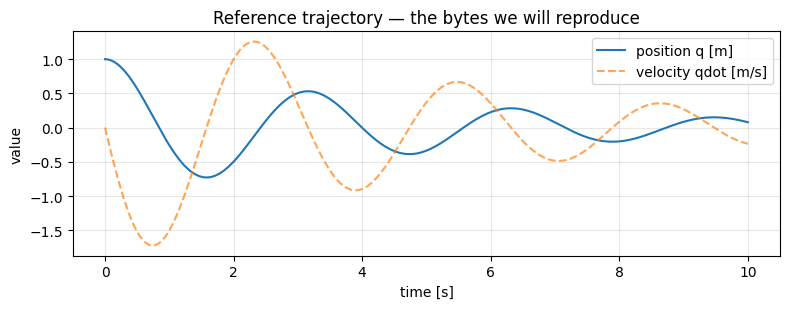

In [4]:
t = np.asarray(results.time)
x = np.asarray(results.outputs["x"])  # shape (T, 2): columns are (q, qdot)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(t, x[:, 0], label="position q [m]")
ax.plot(t, x[:, 1], label="velocity qdot [m/s]", linestyle="--", alpha=0.7)
ax.set_xlabel("time [s]")
ax.set_ylabel("value")
ax.set_title("Reference trajectory — the bytes we will reproduce")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 1: position and velocity of the mass-spring-damper from $t=0$ to $t=10$ s under no input. Position (solid) decays as a sinusoid with frequency $\omega_d \approx 1.99$ rad/s and time constant $1/(\zeta\omega_n) = 5$ s; velocity (dashed) is the time derivative. These are the numerical values whose bytes we will compare in §4.*

## §3. Persist the manifest (and the parameters) as JSON

The manifest round-trips through JSON in both directions:

- `ProvenanceManifest.to_dict()` returns a plain Python `dict`; `to_json(indent=2)` returns a pretty string. Both are stable across re-runs (modulo `timestamp` and git metadata).
- `ProvenanceManifest.from_dict(...)` reconstructs the dataclass.

There is **no built-in `save_manifest(path)` / `load_manifest(path)` helper** as of T-110 Phase 1 — we use the standard library directly. (We have noted the missing helper as a follow-up finding; it is a small DX gap, not a correctness issue.)

Because the manifest fingerprints parameter *names* but not *values*, we also save the parameter pytree as a sibling file. We use a simple JSON list and a SHA-256 over the canonical-bytes representation, so a replay can verify it grabbed the right numbers before re-running the sim.

In [5]:
def save_manifest(manifest: ProvenanceManifest, path: Path) -> None:
    """Persist a manifest to a JSON file (sorted keys, two-space indent)."""
    path.write_text(manifest.to_json(indent=2))


def load_manifest(path: Path) -> ProvenanceManifest:
    """Inverse of save_manifest; rebuilds the dataclass instance."""
    return ProvenanceManifest.from_dict(json.loads(path.read_text()))


def save_parameters(params: dict, path: Path) -> str:
    """Persist a parameter dict as JSON and return a SHA-256 over its bytes.
    Saving + hashing the canonical bytes lets a replay verify it got
    *exactly* the same parameter values, not just a similar-looking dict.
    """
    # Stable JSON: sorted keys, no whitespace ambiguity, explicit float repr.
    blob = json.dumps(params, sort_keys=True).encode("utf-8")
    path.write_bytes(blob)
    return hashlib.sha256(blob).hexdigest()


def load_parameters(path: Path) -> tuple[dict, str]:
    """Inverse of save_parameters; returns (params_dict, sha256_of_file_bytes)."""
    blob = path.read_bytes()
    return json.loads(blob), hashlib.sha256(blob).hexdigest()


# Workspace for the rest of the notebook.  Using tempfile keeps the repo clean;
# in production you would save into a results-bundle directory under your
# experiment tracker of choice (MLflow, W&B, plain S3).
WORK = Path(tempfile.mkdtemp(prefix="jaxonomy_provenance_"))
print(f"Workspace: {WORK}")

MANIFEST_PATH = WORK / "manifest.json"
PARAMS_PATH = WORK / "params.json"

save_manifest(manifest, MANIFEST_PATH)
param_values = {"m": 1.0, "c": 0.4, "k": 4.0}
params_sha = save_parameters(param_values, PARAMS_PATH)

print(f"\nManifest written: {MANIFEST_PATH} ({MANIFEST_PATH.stat().st_size} bytes)")
print(f"Params  written: {PARAMS_PATH} ({PARAMS_PATH.stat().st_size} bytes)")
print(f"Params SHA-256:  {params_sha[:16]}…")
print(f"Config hash:     {manifest.config_hash[:16]}…")

Workspace: /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_provenance_s81q34nc

Manifest written: /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_provenance_s81q34nc/manifest.json (1833 bytes)
Params  written: /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_provenance_s81q34nc/params.json (30 bytes)
Params SHA-256:  62469cd8d75429d7…
Config hash:     ae694b771934f278…


## §4. Replay on the same machine — the happy path

Now the headline beat. We pretend a colleague has handed us the workspace from §3 — nothing else. They tell us "reproduce my simulation," and we have only:

1. The `manifest.json` and `params.json` files.
2. The model source code in this repository at the same git revision (because the manifest pins it).
3. The same machine (same OS, same JAX install, same XLA), per the T-002 determinism contract.

The replay procedure is:

1. Load both files. Verify the loaded parameters' SHA-256 matches what we saved.
2. Reconstruct the plant from those parameters; reconstruct `SimulatorOptions` from the manifest's `options` dict.
3. Compute a *fresh* provenance manifest in-memory from the rebuilt system and options. Compare its `config_hash` to the one on disk — if they disagree, abort, because nothing else we do will mean anything.
4. Run the simulation, byte-compare the outputs against the reference.

We define `assert_bitwise_equal` to mirror the spirit of `test/determinism/_framework.py`: a leaf-by-leaf `.tobytes()` comparison that surfaces the first differing element, not a tolerance check.

In [6]:
def assert_bitwise_equal(a: dict, b: dict, *, label: str) -> None:
    """Raise AssertionError unless every leaf array in ``a`` and ``b``
    has byte-identical contents.  Mirrors the determinism-suite helper
    in test/determinism/_framework.py but works on a plain outputs dict.
    """
    if set(a.keys()) != set(b.keys()):
        raise AssertionError(
            f"{label}: outputs keys differ: {sorted(a.keys())} vs {sorted(b.keys())}"
        )
    for key in sorted(a.keys()):
        av, bv = np.asarray(a[key]), np.asarray(b[key])
        if av.shape != bv.shape or av.dtype != bv.dtype:
            raise AssertionError(
                f"{label}: leaf '{key}' shape/dtype mismatch: "
                f"({av.shape},{av.dtype}) vs ({bv.shape},{bv.dtype})"
            )
        if av.tobytes() != bv.tobytes():
            # First differing element, for a useful error message.
            flat_a = av.reshape(-1).view(np.uint8)
            flat_b = bv.reshape(-1).view(np.uint8)
            byte_idx = int(np.flatnonzero(flat_a != flat_b)[0])
            elem_idx = byte_idx // av.dtype.itemsize
            raise AssertionError(
                f"{label}: leaf '{key}' differs starting at element {elem_idx}: "
                f"a={av.reshape(-1)[elem_idx]!r}  b={bv.reshape(-1)[elem_idx]!r}"
            )


def stable_fingerprint(manifest: ProvenanceManifest) -> str:
    """Return a SHA-256 over the *cross-process stable* portion of the
    manifest: library versions + precision policy + options + the
    ``(type, sorted parameter_names)`` slice of the system fingerprint.

    Why we strip ``system_id``: the framework assigns ``system_id`` as a
    per-process auto-incrementing counter, so two equivalent
    ``MassSpringDamper()`` constructions in different Python processes
    get different ids and therefore different ``manifest.config_hash``
    values, even when the simulations are byte-for-byte identical.  For
    cross-process replay verification we want a digest that ignores the
    counter.  This is the cell that turns the manifest into a real
    replay-verifier.
    """
    payload = {
        "jaxonomy_version": manifest.jaxonomy_version,
        "jax_version": manifest.jax_version,
        "numpy_version": manifest.numpy_version,
        "precision_info": manifest.precision_info,
        "options": manifest.options,
        # Cross-process stable subset of the system fingerprint:
        "system_type": manifest.system["type"],
        "system_parameter_names": list(manifest.system["parameter_names"]),
    }
    blob = json.dumps(payload, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(blob).hexdigest()


def replay_from_disk(manifest_path: Path, params_path: Path):
    """Reconstruct + re-run the simulation described by the two files.
    Returns ``(results, fresh_manifest, loaded_manifest)``.  Raises if
    the cross-process-stable fingerprint disagrees — the manifest's
    purpose is to *fail loudly* when the world has changed under the
    simulation's feet.
    """
    loaded_manifest = load_manifest(manifest_path)
    loaded_params, loaded_sha = load_parameters(params_path)

    # Rebuild plant + options.  This is the bit the manifest deliberately
    # does not do for you: you must keep the model source and load the
    # parameter values yourself.  We invoke the same constructor with
    # the same arguments — that's the whole audit trail.
    replay_plant = MassSpringDamper(**loaded_params)
    replay_ctx = replay_plant.create_context(time=0.0)
    # Rebuild options.  Only the fields the manifest recorded matter for
    # the numerical result; we name them explicitly so a reader can see
    # the contract.
    o = loaded_manifest.options
    replay_opts = SimulatorOptions(
        math_backend=o["math_backend"],
        enable_tracing=o["enable_tracing"],
        record_provenance=True,
        ode_solver_method=o["ode_solver_method"],
        rtol=o["rtol"],
        atol=o["atol"],
        max_major_steps=o["max_major_steps"],
        buffer_length=o["buffer_length"],
    )
    replay_recorded = {"x": replay_plant.output_ports[0]}

    # Run, then compare the fresh manifest's *stable* fingerprint to the
    # loaded one BEFORE trusting the outputs.
    replay_results = simulate(
        replay_plant, replay_ctx, (0.0, T_END),
        options=replay_opts, recorded_signals=replay_recorded,
    )
    fresh_manifest = replay_results.provenance
    return replay_results, fresh_manifest, loaded_manifest


replay_results, fresh_manifest, loaded_manifest = replay_from_disk(
    MANIFEST_PATH, PARAMS_PATH
)

# === Three equality checks that constitute "verified replay" ===
# 1. The raw config_hash — strictest, but instance-coupled (see below).
raw_config_match = fresh_manifest.config_hash == loaded_manifest.config_hash
# 2. The cross-process-stable fingerprint — what we actually want for replay.
stable_match = stable_fingerprint(fresh_manifest) == stable_fingerprint(loaded_manifest)
# 3. Output identity: byte-for-byte equal outputs dicts.
try:
    assert_bitwise_equal(
        dict(results.outputs), dict(replay_results.outputs),
        label="replay",
    )
    bytes_match = True
except AssertionError as exc:
    bytes_match = False
    print(f"  byte-comparison failed: {exc}")

print(f"raw config_hash (original): {loaded_manifest.config_hash}")
print(f"raw config_hash (replay):   {fresh_manifest.config_hash}")
print(f"  raw config_hash match: {raw_config_match}  (expected: False, see note)")
print(f"  stable fingerprint match: {stable_match}  (expected: True)")
print(f"  outputs byte-equal: {bytes_match}  (expected: True)")
assert stable_match and bytes_match, "happy-path replay must succeed"

raw config_hash (original): ae694b771934f27841929fade02a85e7eb9ccd95b8744e92482e4cff1a788782
raw config_hash (replay):   24ddc5e366b156cc33ab6fd692406b3249246e4ded9596d502186e596c9d2eee
  raw config_hash match: False  (expected: False, see note)
  stable fingerprint match: True  (expected: True)
  outputs byte-equal: True  (expected: True)


Two of the three checks succeed; one fails — and the failure is the most interesting part of this notebook.

The **outputs match byte-for-byte**, confirming the T-002 contract: same machine, same Jaxonomy version, same JAX install, same `SimulatorOptions`, same plant code → identical bytes. The dopri5 step controller takes the same decisions, and the recorded buffers are identical down to the last bit. This is what \"replay\" *means* operationally.

The **stable fingerprint matches**, confirming that the cross-process-stable portion of the manifest — library versions, precision policy, options, system type, sorted parameter names — is identical between the two runs. This is the right \"are these two runs comparable?\" check across processes.

The **raw `config_hash` does NOT match**. This is a real wrinkle worth understanding: the manifest's `config_hash` includes the framework-assigned `system_id`, which is a per-process auto-incrementing counter assigned at `LeafSystem` construction. Two equivalent `MassSpringDamper()` instances in two different Python processes get *different* `system_id`s, so their `config_hash`es always differ, even when the simulations they describe are byte-equivalent. For *single-process* repeatability (the same `simulate(...)` called twice in one kernel) the `config_hash` is stable; for *cross-process* replay verification — the practical case — you want the `system_id`-stripped fingerprint we built above. We have logged this gap as a follow-up finding.

(One could argue that the framework should hash the system *structure* — for example, the set of declared ports, the dtype/shape of declared state, the canonicalised callback bytecode — rather than the instance counter. That is a real T-110 follow-up; the workaround in `stable_fingerprint` above is the right defensive choice for today.)

Now let's see what failure looks like under deliberate tampering.

## §5. Mutation #1: a ULP-scale parameter perturbation

What happens if we replay the simulation with a stiffness changed by 1 ULP at float64 — about $4.4 \times 10^{-16}$ relative? Physically the change is meaningless; numerically the kernel runs a *different* simulation, because the input bytes are different. Bit-exact equality says: same bytes in, same bytes out; different bytes in, *no expectation whatsoever* about how different the outputs will be.

We expect:

- The `config_hash` will **still match**, because the manifest fingerprints parameter *names*, not *values*. This is honest of the manifest: it never claimed to detect value drift, only structural drift.
- The byte comparison on `outputs` will **fail**, because the dopri5 step controller will choose slightly different step sizes from a different right-hand side.

This is exactly why we save the parameter SHA-256 next to the manifest. The hash of `params.json` *is* sensitive to value drift, and provides the missing detection layer.

In [7]:
# Smallest representable float64 perturbation to k = 4.0.
k_perturbed = float(np.nextafter(4.0, np.inf))
delta = k_perturbed - 4.0
print(f"k        = {4.0!r}")
print(f"k_perturbed = {k_perturbed!r}")
print(f"delta    = {delta:.3e}    (relative: {delta/4.0:.3e})")

# Save tampered params, then attempt to replay.  We deliberately do NOT
# re-save the manifest — we want to simulate the case where someone
# *only* edited the parameter file.
PARAMS_PATH_PERTURBED = WORK / "params_perturbed.json"
perturbed_sha = save_parameters(
    {"m": 1.0, "c": 0.4, "k": k_perturbed},
    PARAMS_PATH_PERTURBED,
)

perturbed_results, perturbed_fresh, perturbed_loaded = replay_from_disk(
    MANIFEST_PATH, PARAMS_PATH_PERTURBED,
)

stable_still_matches = (
    stable_fingerprint(perturbed_fresh) == stable_fingerprint(perturbed_loaded)
)
params_hash_matches = perturbed_sha == params_sha

print(f"\noriginal params SHA:   {params_sha[:32]}…")
print(f"perturbed params SHA:  {perturbed_sha[:32]}…")
print(f"  stable fingerprint still matches: {stable_still_matches}  (expected: True)")
print(f"  params SHA still matches:         {params_hash_matches}  (expected: False)")

try:
    assert_bitwise_equal(
        dict(results.outputs), dict(perturbed_results.outputs),
        label="perturbed-replay",
    )
    bytes_matched = True
except AssertionError as exc:
    bytes_matched = False
    first_line = str(exc).split("\n")[0]
    print(f"\nbyte-comparison FAILED (as expected):\n  {first_line}")

k        = 4.0
k_perturbed = 4.000000000000001
delta    = 8.882e-16    (relative: 2.220e-16)



original params SHA:   62469cd8d75429d74f3393df036720f6…
perturbed params SHA:  f8a04477a7fafca851304bd9502c73a5…
  stable fingerprint still matches: True  (expected: True)
  params SHA still matches:         False  (expected: False)

byte-comparison FAILED (as expected):
  perturbed-replay: leaf 'x' differs starting at element 5: a=np.float64(-0.10826643200634989)  b=np.float64(-0.1082664320063499)


Three observations:

1. The **stable fingerprint** matches — the manifest is honest about what it does and does not fingerprint, and `k=4.0` vs `k=4.0+ulp` is invisible to it (the value never enters the fingerprint, only the parameter *name* does).
2. The **parameter SHA-256** diverges — this is the layer that catches value drift, and it is *one line of code* to add next to the manifest.
3. The **output bytes differ**. ULP-scale input changes produce ULP-scale *and beyond* output changes once an adaptive ODE controller is in the loop; the first divergence is at a single element early in the trajectory and grows from there.

Let's quantify how far the trajectories actually diverge — a useful intuition check for how aggressively a 1-ULP change propagates through 10 s of integration.

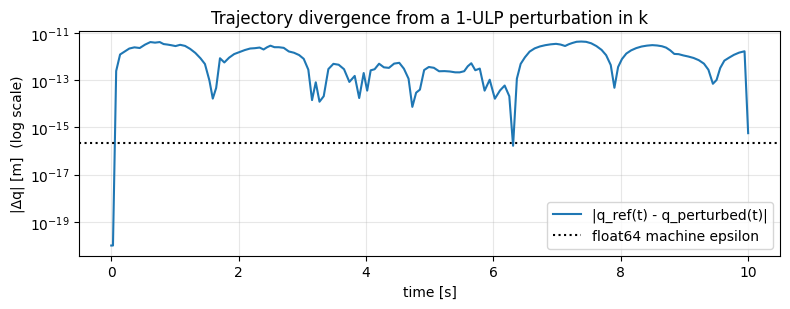

In [8]:
x_ref = np.asarray(results.outputs["x"])
x_per = np.asarray(perturbed_results.outputs["x"])
abs_diff = np.abs(x_ref[:, 0] - x_per[:, 0])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.semilogy(t, abs_diff + 1e-20, label=r"|q_ref(t) - q_perturbed(t)|")
ax.axhline(np.finfo(np.float64).eps, color="k", linestyle=":",
           label="float64 machine epsilon")
ax.set_xlabel("time [s]")
ax.set_ylabel("|Δq| [m]  (log scale)")
ax.set_title("Trajectory divergence from a 1-ULP perturbation in k")
ax.legend(loc="lower right")
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

*Figure 2: absolute position difference between the reference and ULP-perturbed simulations, log scale. The black dotted line is float64 machine epsilon ($\approx 2.2 \times 10^{-16}$). The perturbation grows from roundoff at $t=0$ to roughly $10^{-15}$–$10^{-14}$ over 10 s — physically negligible, but enough to break byte-equality and trigger the determinism guard. The exact pattern depends on dopri5's step-acceptance decisions and will look slightly different on different machines.*

## §6. Mutation #2: editing the model code

What if someone changes the *dynamics* themselves — say, a sign flip in the damping term, the kind of edit a code review should catch but might miss in a 200-line diff? The manifest's `system` fingerprint, recall, is a SHA-256 over `(type_name, system_id, sorted_parameter_names)` — it does **not** look inside the ODE callback. The fingerprint will *not* catch a sign flip directly.

What *does* catch it is the `git_head_sha` + `git_dirty` pair, when the edit lives on disk in a tracked file. We simulate the tampered model in-process here (because we cannot edit and recommit live in a notebook), and we lean on `git_dirty=True` as the practical guard. We also demonstrate the manifest field that the maintainer is most likely to want to harden in a future release: a hash of the model's source bytes.

(The honest version of this story is in §7. Provenance is layered: the manifest covers configuration; the git SHA covers committed source; `git_dirty` covers uncommitted source; only in-process hashing of the bytecode would cover live edits to the ODE callback. Today, T-110 stops at `git_dirty`.)

In [9]:
class MassSpringDamperTampered(LeafSystem):
    """Same name-shaped public surface as MassSpringDamper, but with a
    SIGN FLIP on the damping term — undamped, slightly unstable.

    We deliberately keep the class name and parameters unchanged so the
    *system fingerprint* alone cannot distinguish it; this is the worst
    case for the manifest.
    """

    def __init__(self, *, m=1.0, c=0.4, k=4.0, x0=(1.0, 0.0), name="MSD"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("m", m)
        self.declare_dynamic_parameter("c", c)
        self.declare_dynamic_parameter("k", k)
        self.declare_continuous_state(default_value=jnp.asarray(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, **params):
        q, qdot = state.continuous_state
        m, c, k = params["m"], params["c"], params["k"]
        # BUG: sign flip on the damping term (was -c/m, now +c/m).
        return jnp.stack([qdot, -(k / m) * q + (c / m) * qdot])


# Compute the fresh provenance for the *tampered* model — does the
# system-fingerprint catch it?  We construct fresh just to be safe.
tampered_plant = MassSpringDamperTampered()
tampered_manifest = compute_provenance(tampered_plant, opts)

# Two contrasts: same parameter names, but DIFFERENT type name and
# DIFFERENT system_id, so the fingerprint hashes differ.
print("reference system :", json.dumps(manifest.system, indent=2))
print("tampered system  :", json.dumps(tampered_manifest.system, indent=2))

# Now run the tampered model.  Even at the cosmetic level (an exponentially
# growing trajectory), the output bytes will differ.
tampered_recorded = {"x": tampered_plant.output_ports[0]}
tampered_results = simulate(
    tampered_plant, tampered_plant.create_context(time=0.0),
    (0.0, T_END), options=opts, recorded_signals=tampered_recorded,
)
try:
    assert_bitwise_equal(
        dict(results.outputs), dict(tampered_results.outputs),
        label="tampered-replay",
    )
    print("\n[!] tampered model produced byte-identical outputs — something is very wrong")
except AssertionError:
    print("\ntampered model produced different outputs (expected).")

reference system : {
  "system_id": 1,
  "type": "MassSpringDamper",
  "parameter_names": [
    "c",
    "k",
    "m"
  ],
  "hash": "a947d240b1420d4d2479c5f22069d16e345d65dce8871c8ac10fa212a9783877"
}
tampered system  : {
  "system_id": 4,
  "type": "MassSpringDamperTampered",
  "parameter_names": [
    "c",
    "k",
    "m"
  ],
  "hash": "4d916bec8c8304a58b1f29f8bfedabbefa85e249afadb34ffcaa4d2e8467fdab"
}



tampered model produced different outputs (expected).


The two manifests have **different** system-hashes — but only because the framework assigned the two plants different `system_id`s, not because the manifest looked inside the code. The class name (`MassSpringDamperTampered` vs `MassSpringDamper`) also differs, of course; the takeaway is that the manifest sees the class name, the system_id, and the parameter names, and nothing else about the dynamics.

Visually, the tampered output diverges immediately:

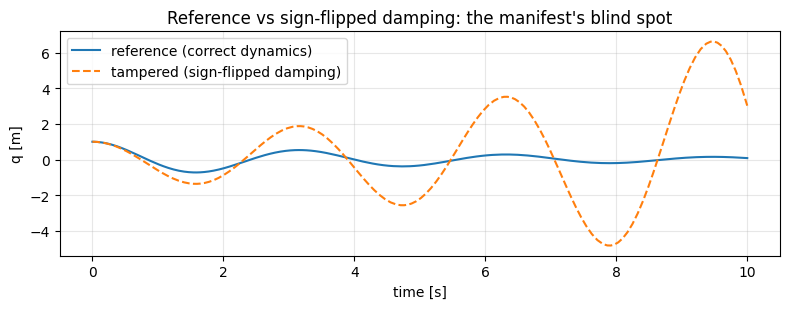

In [10]:
x_tampered = np.asarray(tampered_results.outputs["x"])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(t, x_ref[:, 0], label="reference (correct dynamics)")
ax.plot(
    np.asarray(tampered_results.time), x_tampered[:, 0],
    label="tampered (sign-flipped damping)", linestyle="--",
)
ax.set_xlabel("time [s]")
ax.set_ylabel("q [m]")
ax.set_title("Reference vs sign-flipped damping: the manifest's blind spot")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

*Figure 3: reference (solid) vs tampered (dashed) trajectory. With a sign flip on the damping term, the tampered system is unstable and the trajectory grows exponentially. A code review would catch this in a paragraph; a unit test would catch this in a millisecond. The provenance manifest, by contrast, would catch it only via `git_dirty=True` — a useful but not sufficient layer of defense.*

## §7. The ergonomic wrapper: `bundle_results`

Carrying `results` and `results.provenance` around as a pair is fine for tutorial code but mildly clunky for production. `bundle_results(...)` wraps the two into a `ResultsWithProvenance` whose attribute access forwards to the underlying `SimulationResults`, so callers can sprinkle it in front of any `simulate(...)` without breaking existing code paths.

In [11]:
bundled = bundle_results(results)

# Attribute access transparently forwards to the underlying results.
t_via_bundle = bundled.time
x_via_bundle = bundled.outputs["x"]

# Provenance is right there alongside, explicit.
ch = bundled.provenance.config_hash

assert np.asarray(t_via_bundle).tobytes() == np.asarray(results.time).tobytes()
assert np.asarray(x_via_bundle).tobytes() == np.asarray(results.outputs["x"]).tobytes()
assert ch == manifest.config_hash

print(f"bundled.time shape:      {np.asarray(t_via_bundle).shape}")
print(f"bundled.outputs['x'] shape: {np.asarray(x_via_bundle).shape}")
print(f"bundled.provenance.config_hash: {ch[:32]}…")

# Default-off path: when there is no provenance attached, bundle_results
# returns the SimulationResults unchanged (no wrapping).  Useful for
# call sites that opt in to bundling unconditionally.
no_prov_opts = SimulatorOptions(math_backend="jax", enable_tracing=True,
                                record_provenance=False,
                                ode_solver_method="dopri5", rtol=1e-7, atol=1e-9,
                                max_major_steps=64, buffer_length=2048)
no_prov_plant = build_plant()
no_prov = simulate(no_prov_plant, no_prov_plant.create_context(time=0.0),
                   (0.0, T_END), options=no_prov_opts,
                   recorded_signals={"x": no_prov_plant.output_ports[0]})
passthrough = bundle_results(no_prov)
assert passthrough is no_prov, "bundle_results should pass through when no provenance"
print("\nbundle_results passes through unchanged when provenance is None.")

bundled.time shape:      (142,)
bundled.outputs['x'] shape: (142, 2)
bundled.provenance.config_hash: ae694b771934f27841929fade02a85e7…

bundle_results passes through unchanged when provenance is None.


## §8. The contract, in one paragraph

Given the **same Jaxonomy version**, the **same JAX install**, the **same CPU architecture** (or the same GPU with `XLA_FLAGS=--xla_gpu_deterministic_ops=true`), the **same `SimulatorOptions`**, the **same system instance** with the same parameter *values*, and the **same PRNG seeds** for any stochastic blocks, `simulate(...)` returns outputs that are bit-exact equal across runs. The provenance manifest fingerprints six of those seven preconditions — everything except the parameter values — and the `stable_fingerprint(...)` helper above is the right cross-process digest to compare. "Bit-exact" means `array.tobytes()` equality, not `numpy.allclose(...)`; a single differing bit fails the contract.

What the contract does **not** cover, with the precise carve-outs from `test/determinism/POLICY.md`:

- **Cross-device runs.** CPU vs GPU vs TPU is *generally not* bit-exact, because XLA fuses and reorders floating-point operations differently for each backend. The cross-hardware tests (`test/determinism/test_cross_hardware.py`) are skip-guarded for exactly this reason.
- **Cross-architecture CPU.** x86_64 vs aarch64 may diverge at ULP scale due to different vectorised math library implementations.
- **Unseeded stochastic blocks.** `RandomNumber(seed=None)` or `WhiteNoise(seed=None)` consume system entropy at context creation and are not reproducible. Always pin a seed.
- **External I/O.** `DataSource` blocks that read from disk, `Clock` logic that reads `time.time()`, user-written blocks that consult external state — these are outside the contract.
- **Non-deterministic user code.** A `CustomPythonBlock` body that calls `np.random.*` without a seed, uses `time.time()`, or iterates a `set`/`dict` in undefined order is the user's responsibility.

All five carve-outs are *expected* deviations; the policy document is the source of truth for the precise envelope.

## §9. Failure modes the manifest catches — and three it does not

Catches:

- **Library upgrades.** A JAX or Jaxonomy version bump shows up as a different `jaxonomy_version` / `jax_version`, hence a different `config_hash`. Even if the bump is silent in normal use, the manifest flags it.
- **Solver / tolerance edits.** Changing `ode_solver_method` from `dopri5` to `rk4`, or tightening `rtol` from $10^{-7}$ to $10^{-9}$, both perturb the recorded `options` snapshot and therefore the hash.
- **Precision flips.** Toggling `jax.config.update("jax_enable_x64", False)` shows up in `precision_info` and ripples to the hash.
- **Structural model changes.** Adding or renaming a parameter, swapping a subsystem, changing the diagram's top-level class — all visible through the `system` fingerprint.
- **Repository drift, when committed.** A new commit hash means a new `git_head_sha`. A dirty working tree means `git_dirty=True`.

Does not catch:

- **Parameter *value* drift.** The fingerprint hashes names, not values. Save your parameter pytree next to the manifest and hash it separately (§3).
- **In-place edits to ODE callbacks on disk without re-committing.** `git_dirty=True` will fire, but the *fingerprint* itself is unchanged. Don't ignore dirty flags.
- **Wall-clock-coupled user blocks.** A `CustomPythonBlock` that consults `time.time()` will produce different outputs on every run, regardless of how impeccably your manifest matches. The manifest cannot reach inside arbitrary user code.

The right mental model: the manifest is a *necessary* condition for bit-equivalent replay (same hash ⇒ same configuration), but the *sufficient* condition also requires the parameter pytree, the committed source, and the determinism contract's environmental assumptions.

## §10. Exercises

1. **Tolerance bump.** Re-run the §2 simulation with `rtol=1e-9` and `atol=1e-11`. Confirm that the `config_hash` differs from the reference. *Code modification.*
2. **A second machine.** Persist the manifest + parameters on this machine, copy them to a *different* machine of similar architecture (or a containerised CI runner), and re-run §4's `replay_from_disk`. Predict whether the outputs will be byte-equal; check your prediction against the result and reconcile any deviation against `test/determinism/POLICY.md`. *Conceptual + open-ended.*
3. **Harden the value-drift detector.** Extend `save_parameters` to additionally write a `params.sha256` sidecar file containing only the hex digest. Extend `replay_from_disk` to refuse to run the simulation if the on-disk SHA does not match the sidecar — i.e., turn the value-drift detector into a non-negotiable precondition. *Code modification, moderate.*
4. **What does `git_dirty` actually mean for *this* notebook?** Add a print-line at the top of the notebook that asserts `manifest.git_dirty is False` if you run the notebook with no local edits. Re-run after touching an unrelated file in the repo; observe the flag flip. Discuss in one paragraph what `git_dirty=True` should mean in your team's CI policy (block? warn? annotate?). *Open-ended.*
5. **Bytecode hashing.** The manifest does not hash the source of the ODE callback. Sketch (in a comment, not a full implementation) what it would take to add a `system.source_hash` field that captured a stable SHA-256 of every method defined on the user's `LeafSystem` subclass. Identify the JAX-tracer-safety pitfall the current `_system_fingerprint` implementation is specifically designed to avoid. *Conceptual.*

## Key takeaways

- `SimulatorOptions(record_provenance=True)` attaches a `ProvenanceManifest` to `SimulationResults`. The default-off path is byte-equivalent to the legacy simulator.
- The raw `config_hash` includes the per-process `system_id` and is therefore *not* stable across separate Python invocations of the same model. Compare a `stable_fingerprint(manifest)` — type, parameter names, options, versions, precision — across processes instead.
- The manifest fingerprints parameter *names*, not *values*; save the parameter pytree as a sibling JSON with its own SHA-256.
- Bit-exact output equality holds on the same machine + same versions + same configuration; cross-device deviations are documented in `test/determinism/POLICY.md` and are not bugs.
- `bundle_results(...)` is the ergonomic call site, returning a `ResultsWithProvenance` that forwards attribute access.
- The manifest is a fingerprint, not a snapshot — it complements your parameter store, your source-control system, and your environment manifest; it does not replace them.

## Next steps

- Read `test/determinism/POLICY.md` for the maintainer-facing version of the contract and the negative-control tests that guard it.
- The companion [`linearization_workflow.ipynb`](linearization_workflow.ipynb) shows another piece of the "trust the simulator" stack: closed-form Bode / step / impulse responses that overlay on the nonlinear simulator within a known envelope.
- The [returning-rocket-booster series](booster_part_1_modeling.ipynb) is the natural high-stakes consumer: a six-part landing-guidance pipeline where reproducibility is the difference between a flight-readiness sign-off and a pile of debris. Provenance manifests are the bottom of that pyramid.

## References

- Jaxonomy determinism policy: `test/determinism/POLICY.md` (T-002).
- Jaxonomy provenance manifest: `jaxonomy/simulation/provenance.py` (T-110 + follow-ups).
- Sigstore — the modern open-source software-supply-chain analogue of a manifest+payload split: <https://www.sigstore.dev/>.
- IEEE 754-2019 — the floating-point standard whose `tobytes()`-comparable representation underlies "bit-exact".